# Neural Networks Approach

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
import matplotlib.pyplot as plt

# Covid

In [2]:
df_covid = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/covid_data_weekly.csv')
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Country: Brazil, RMSE: 187540.60, R2: 0.97


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Country: Chile, RMSE: 256648.11, R2: 0.15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Country: Panama, RMSE: 12033.96, R2: 0.77


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Country: US, RMSE: 12960497.40, R2: -12.50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Country: Uruguay, RMSE: 51331.04, R2: -4.46


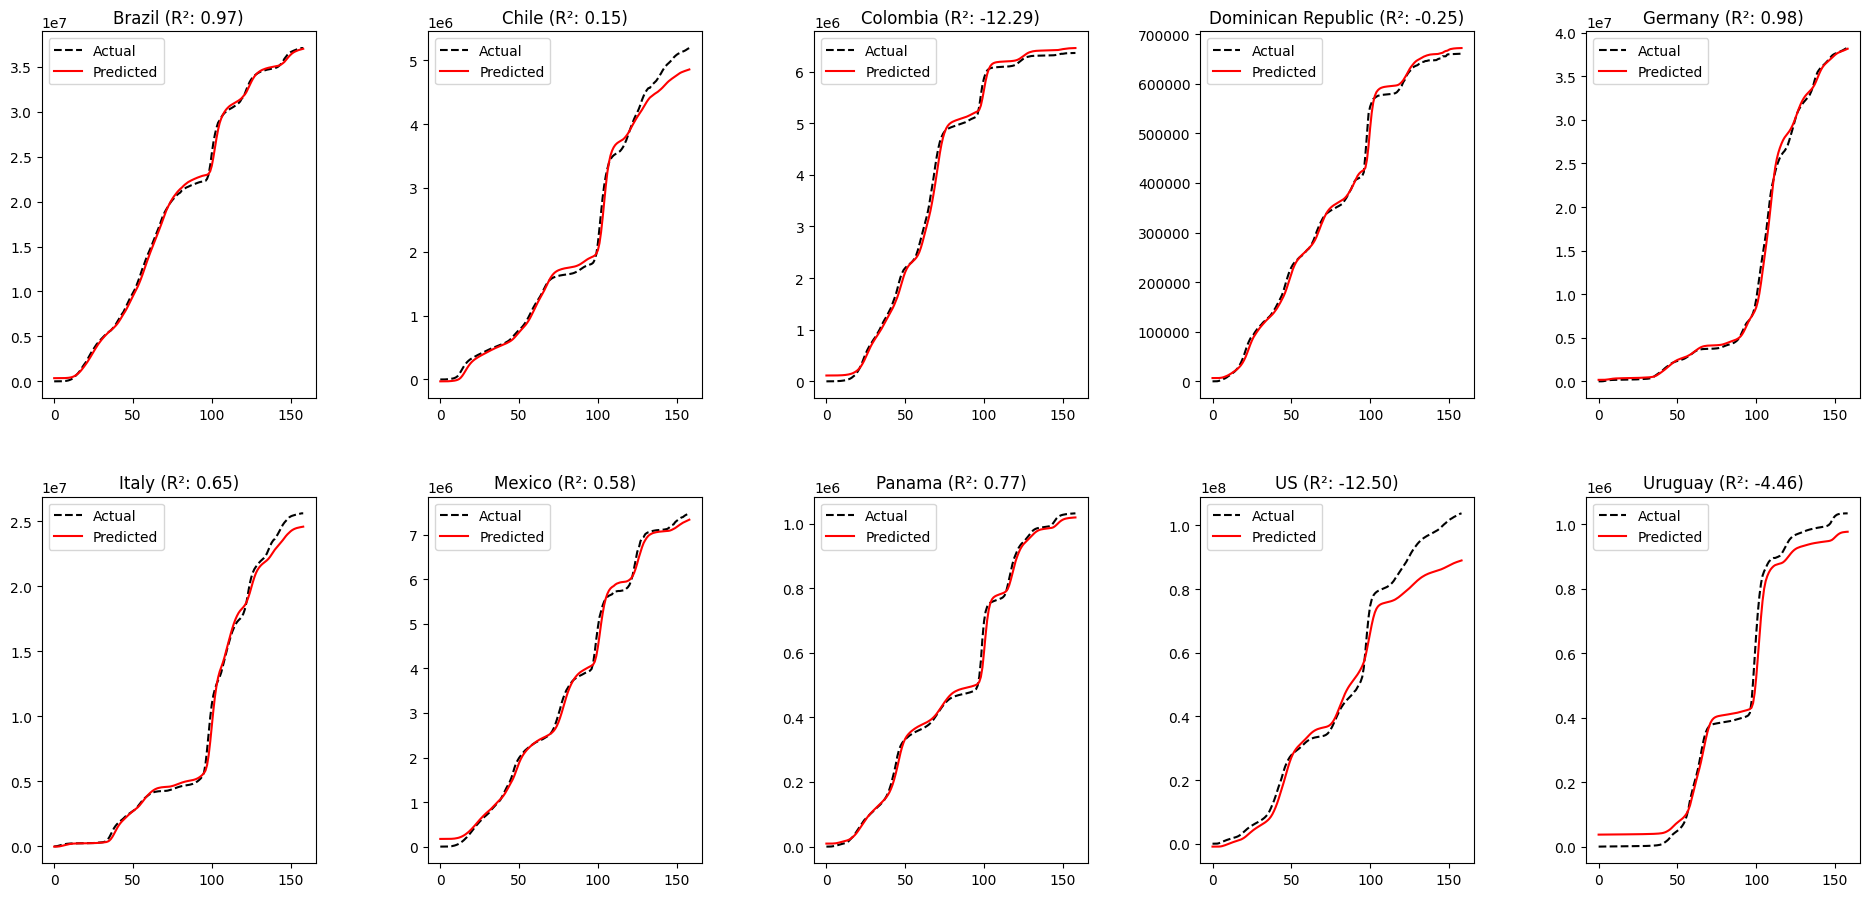

In [3]:
# Function to create sequences for GRU
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Get unique countries
countries = df_covid['country'].unique()

# initiate a metrics dict
metrics = {}

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.tight_layout(pad=5.0)


# Loop through each country
for i, country in enumerate(countries):
    # Filter data for the current country
    df_country = df_covid[df_covid['country'] == country].copy()

    # Define target variable (y)
    y = df_country['cases'].values.reshape(-1, 1)

    # Scale data
    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(y)

    # Train-test split (before lagging)
    train_size = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_size], y_scaled[train_size:]

    # Create sequences for the full dataset (Train + Test)
    seq_length = 5  # Number of previous time steps used for prediction
    X_full, y_full = create_sequences(y_scaled, seq_length)

    # Split full sequences into train and test
    X_train, y_train = X_full[:train_size-seq_length], y_full[:train_size-seq_length]
    X_test, y_test = X_full[train_size-seq_length:], y_full[train_size-seq_length:]

    # Reshape input to be [samples, time steps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))  # For full dataset prediction

    # Build the GRU model
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')

    # Train the model
    model.fit(X_train, y_train, epochs=50, batch_size=72, verbose=0, shuffle=False)

    # Make predictions for the full dataset
    y_pred_full = model.predict(X_full)

    # Extract only test predictions for evaluation
    y_pred_test = y_pred_full[train_size-seq_length:]

    # Inverse transform to get actual values
    y_full = scaler.inverse_transform(y_full.reshape(-1, 1))
    y_pred_full = scaler.inverse_transform(y_pred_full.reshape(-1, 1))
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_test = scaler.inverse_transform(y_pred_test.reshape(-1, 1))

    # Evaluate the model (ONLY on test set)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)
    metrics[country] = {'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"Country: {country}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

    # Plot actual vs predicted (FULL DATASET)
    row = i // 5
    col = i % 5
    axes[row, col].plot(y_full, label='Actual', color='black', linestyle='dashed')
    axes[row, col].plot(y_pred_full, label='Predicted', color='red')
    axes[row, col].set_title(f"{country} (R²: {r2:.2f})")
    axes[row, col].legend()

plt.show()



## Metrics on the test set

In [4]:
# create a metrics dataframe based on the dict metrics
metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={'index': 'country'}, inplace=True)
metrics_df

,country,RMSE,R2
0,Brazil,1.875406e+05,0.968868
1,Chile,2.566481e+05,0.145602
2,Colombia,9.040470e+04,-12.287196
3,Dominican Republic,1.023540e+04,-0.245758
4,Germany,3.035475e+05,0.984510
5,Italy,9.004375e+05,0.652782
6,Mexico,1.172617e+05,0.575095
7,Panama,1.203396e+04,0.766065
8,US,1.296050e+07,-12.500582
9,Uruguay,5.133104e+04,-4.457185


# Understanding the GRU Model for COVID-19 Forecasting

## 1. What is the Input to the GRU Network?
The input to the GRU model is a **sequence of past COVID-19 cases**. Given a time series:

$$ y_1, y_2, y_3, \dots, y_T $$

We create **overlapping sequences** of length \( seq\_length = 5 \) to predict the next value.

For example, if the time series looks like:
\[
\{100, 150, 180, 220, 250, ?\}
\]

Then the **GRU input** is:

$$ X = [100, 150, 180, 220, 250] $$

And the target (to predict) is:

$$ y = \text{Next value in series} $$

Thus, each training sample consists of:

$$ X = [y_t, y_{t-1}, y_{t-2}, y_{t-3}, y_{t-4}] $$
$$ y = y_{t+1} $$

## 2. What is the GRU Forecasting?
The GRU model predicts **the next time step** given the past 5 values.

- Given **5 past cases**, it predicts the **6th case**.
- Given **6 past cases**, it predicts the **7th case**.
- This process continues until the end of the dataset.

## 3. Train-Test Split Strategy
We split the dataset **before creating sequences**:

- **Train data:** First 80% of cases
- **Test data:** Last 20% of cases

## 4. Model Training Process
1. **Normalization:** Cases are scaled between 0 and 1.
2. **Train-Test Split:** Data is divided into 80% training and 20% testing.
3. **Sequence Generation:** Each sample consists of **5 previous timesteps**.
4. **GRU Training:** The model learns patterns in training data.
5. **Prediction:** The trained model forecasts the entire dataset.
6. **Evaluation:** RMSE & R² are computed only on the test set.

## 5. Summary Table
| Step | Action |
|------|--------|
| 1. Data Processing | Normalize cases, create sequences |
| 2. Input to GRU | Past 5 values (e.g., Days 1-5) |
| 3. Target (y) | Next value (e.g., Day 6) |
| 4. Training | GRU learns patterns on train data (80%) |
| 5. Forecasting | Predicts entire series (Train + Test) |
| 6. Evaluation | Computes RMSE & R² only on test set |

## 6. Key Takeaways
- The GRU network sees **5 past cases** as input to predict the **next case**.
- It is a **one-step-ahead forecasting model**.
- The model is trained **only on training data but predicts for the entire dataset**.
- **Test set evaluation is separate** to prevent overfitting.


## Non-cheating RNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━

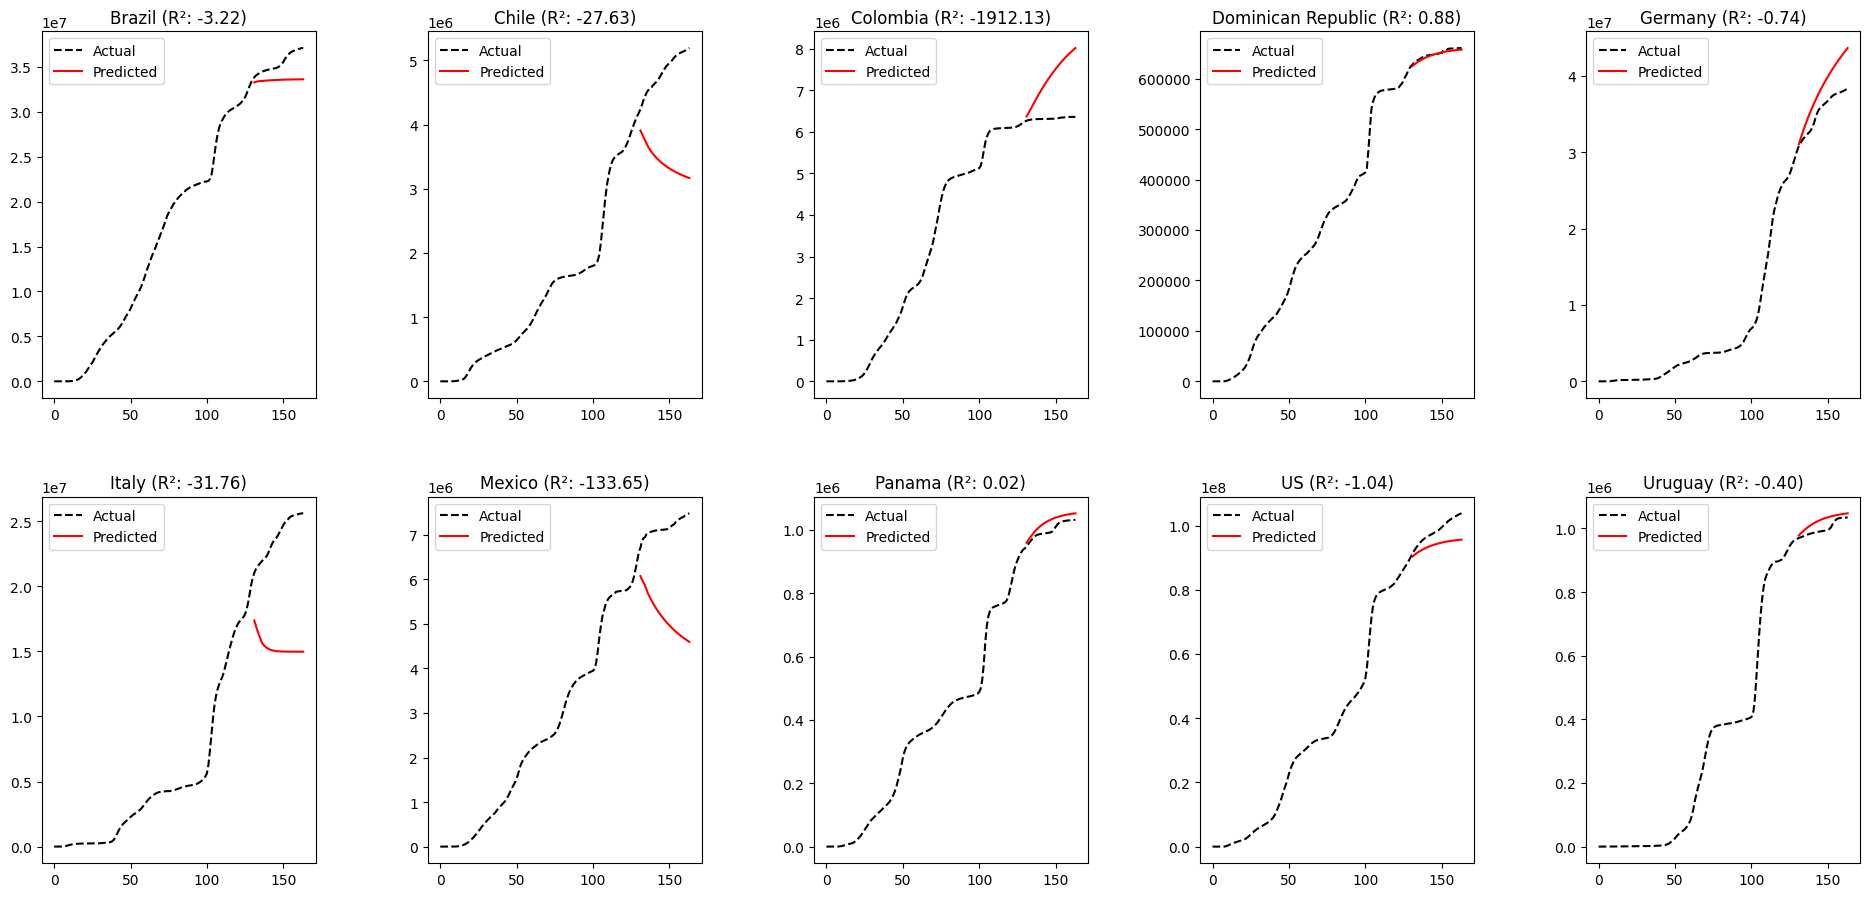

In [6]:
# Function to create sequences for GRU
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Get unique countries
countries = df_covid['country'].unique()

# initiate a metrics dict
metrics = {}

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.tight_layout(pad=5.0)

seq_length = 5

# Loop through each country
for i, country in enumerate(countries):
    df_country = df_covid[df_covid['country'] == country].copy()

    y = df_country['cases'].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(y)

    # Train-test split (80% train, 20% test)
    train_size = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_size], y_scaled[train_size:]

    # Create sequences for train set
    X_train, y_train = create_sequences(train, seq_length)
    X_train = X_train.reshape((X_train.shape[0], seq_length, 1))

    # Build GRU model
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=(seq_length, 1)))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')

    # Train model
    model.fit(X_train, y_train, epochs=50, batch_size=72, verbose=0, shuffle=False)

    # Iterative predictions on test data
    predictions = []
    current_batch = train[-seq_length:].reshape((1, seq_length, 1))

    for j in range(len(test)):
        pred = model.predict(current_batch)[0]
        predictions.append(pred)
        current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)


    # Inverse transform predictions
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actual = scaler.inverse_transform(test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    r2 = r2_score(actual, predictions)
    metrics[country] = {'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"Country: {country}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

    # Plot actual vs predicted
    row = i // 5
    col = i % 5
    axes[row, col].plot(range(len(y_scaled)), scaler.inverse_transform(y_scaled), label='Actual', color='black', linestyle='dashed')
    axes[row, col].plot(range(train_size, train_size + len(predictions)), predictions, label='Predicted', color='red')
    axes[row, col].set_title(f"{country} (R²: {r2:.2f})")
    axes[row, col].legend()

plt.show()

In [7]:
# create a metrics dataframe based on the dict metrics
metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={'index': 'country'}, inplace=True)
metrics_df

,country,RMSE,R2
0,Brazil,2.183957e+06,-3.221867
1,Chile,1.485566e+06,-27.626484
2,Colombia,1.084791e+06,-1912.125677
3,Dominican Republic,3.208037e+03,0.877622
4,Germany,3.220577e+06,-0.743714
5,Italy,8.746436e+06,-31.761007
6,Mexico,2.087454e+06,-133.652343
7,Panama,2.465070e+04,0.018395
8,US,5.042903e+06,-1.043950
9,Uruguay,2.595574e+04,-0.395325


# Epidemics

In [8]:
df_dengue = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/dengue_no_split.csv')
df_zika = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/zika.csv')
df_chic = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/chicunguya.csv')
df_varicela = pd.read_csv('https://raw.githubusercontent.com/danielgvb/thesis/refs/heads/main/Data/silver/varicela.csv')

In [9]:
df_dengue.head()

,SEMANA,ANO,Casos,DATE
0,1,2007,315,2007-01-01
1,2,2007,236,2007-01-08
2,3,2007,252,2007-01-15
3,4,2007,305,2007-01-22
4,5,2007,360,2007-01-29


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Dengue: RMSE = 24495.03, R² = 0.78


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Zika: RMSE = 226.16, R² = -47.36


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Chikungunya: RMSE = 63.85, R² = -1.11


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Varicela: RMSE = 7855.49, R² = 0.87


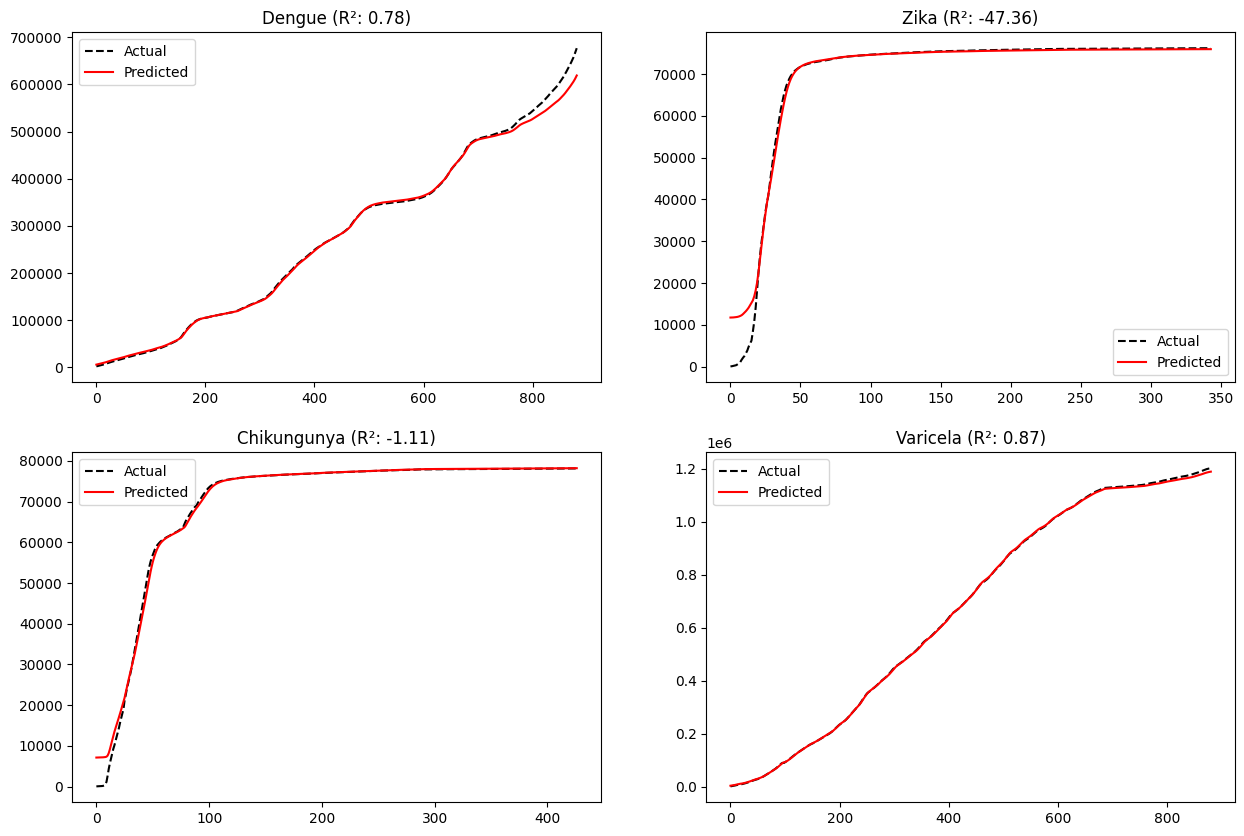

In [10]:
# Function to create sequences for GRU
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Dictionary of datasets
datasets = {
    "Dengue": df_dengue,
    "Zika": df_zika,
    "Chikungunya": df_chic,
    "Varicela": df_varicela
}

# Set up subplots for visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
metrics = {}

# Loop through each dataset
for i, (name, df) in enumerate(datasets.items()):
    # Ensure DATE is in datetime format
    df['DATE'] = pd.to_datetime(df['DATE'])

    # Sort by date
    df = df.sort_values(by='DATE')

    # Compute cumulative cases
    df['cases'] = df['Casos'].cumsum()

    # Normalize the data
    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(df['cases'].values.reshape(-1, 1))

    # Train-test split (before sequence creation)
    train_size = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_size], y_scaled[train_size:]

    # Create sequences for the full dataset
    seq_length = 5  # Number of previous time steps
    X_full, y_full = create_sequences(y_scaled, seq_length)

    # Split into train and test sequences
    X_train, y_train = X_full[:train_size-seq_length], y_full[:train_size-seq_length]
    X_test, y_test = X_full[train_size-seq_length:], y_full[train_size-seq_length:]

    # Reshape for GRU model
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))

    # Build GRU model
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')

    # Train the model
    model.fit(X_train, y_train, epochs=50, batch_size=72, verbose=0, shuffle=False)

    # Make predictions on the full dataset
    y_pred_full = model.predict(X_full)

    # Extract only test predictions for evaluation
    y_pred_test = y_pred_full[train_size-seq_length:]

    # Inverse transform to get actual values
    y_full = scaler.inverse_transform(y_full.reshape(-1, 1))
    y_pred_full = scaler.inverse_transform(y_pred_full.reshape(-1, 1))
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_test = scaler.inverse_transform(y_pred_test.reshape(-1, 1))

    # Evaluate the model (ONLY on test set)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)
    metrics[name] = {'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{name}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

    # Plot actual vs predicted (FULL DATASET)
    axes[i].plot(y_full, label='Actual', color='black', linestyle='dashed')
    axes[i].plot(y_pred_full, label='Predicted', color='red')
    axes[i].set_title(f"{name} (R²: {r2:.2f})")
    axes[i].legend()

plt.show()


In [11]:
metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={'index': 'disease'}, inplace=True)
metrics_df

,disease,RMSE,R2
0,Dengue,24495.033697,0.781817
1,Zika,226.160655,-47.358644
2,Chikungunya,63.854898,-1.105623
3,Varicela,7855.488310,0.866058


## Non-Cheating RNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Dengue: RMSE = 81479.56, R² = -1.41


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Zika: RMSE = 61.35, R² = -2.56


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Chikungunya: RMSE = 1296.52, R² = -867.06


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Varicela: RMSE = 76295.49, R² = -11.63


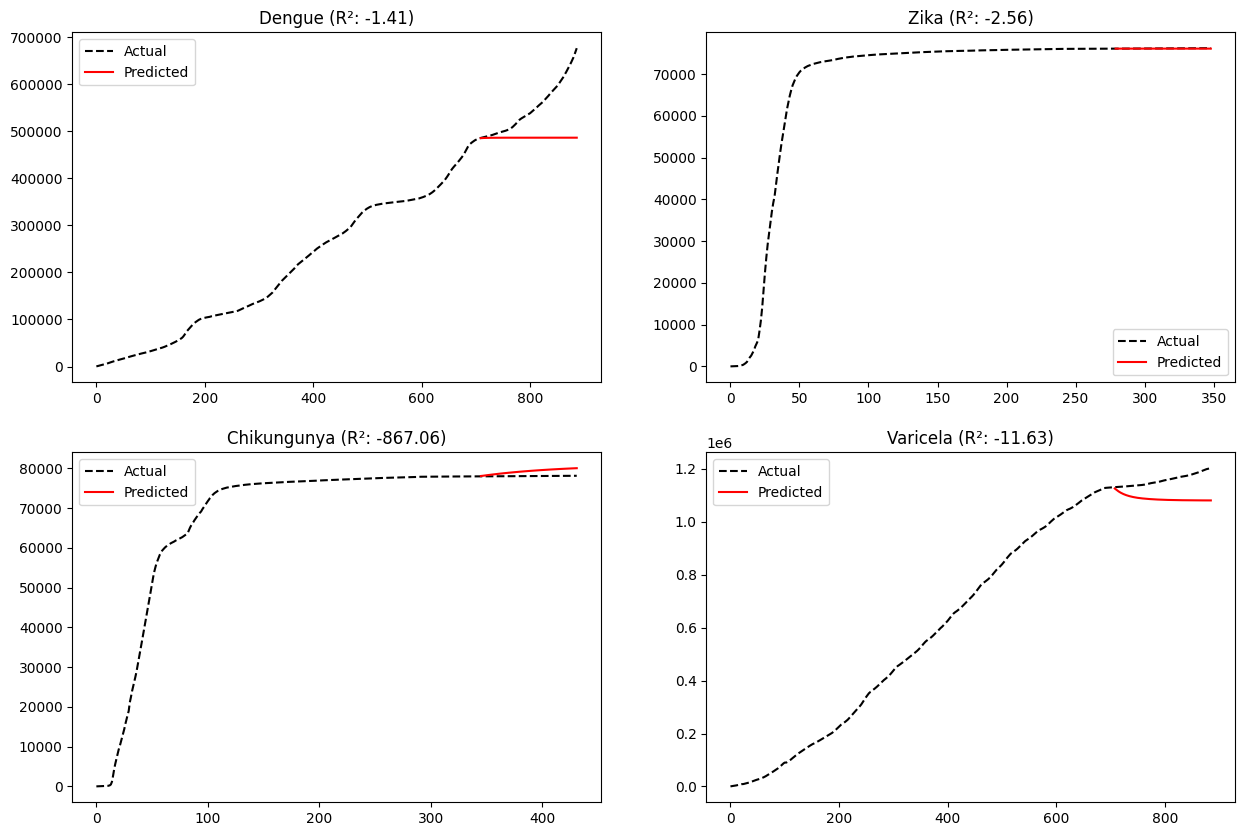

In [13]:
# Function to create sequences for GRU
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Dictionary of datasets
datasets = {
    "Dengue": df_dengue,
    "Zika": df_zika,
    "Chikungunya": df_chic,
    "Varicela": df_varicela
}

# Set up subplots for visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
metrics = {}

# Loop through each dataset
for i, (name, df) in enumerate(datasets.items()):
    # Ensure DATE is in datetime format
    df['DATE'] = pd.to_datetime(df['DATE'])

    # Sort by date
    df = df.sort_values(by='DATE')

    # Compute cumulative cases
    df['cases'] = df['Casos'].cumsum()

    # Normalize the data
    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(df['cases'].values.reshape(-1, 1))

    # Train-test split (before sequence creation)
    train_size = int(len(y_scaled) * 0.8)
    train, test = y_scaled[:train_size], y_scaled[train_size:]

    # Create sequences for train set only
    seq_length = 5  # Number of previous time steps
    X_train, y_train = create_sequences(train, seq_length)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

    # Build GRU model
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=(seq_length, 1)))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')

    # Train the model
    model.fit(X_train, y_train, epochs=50, batch_size=72, verbose=0, shuffle=False)

    # Iterative predictions on test data
    predictions = []
    current_batch = train[-seq_length:].reshape((1, seq_length, 1))

    for j in range(len(test)):
        pred = model.predict(current_batch, verbose=0)[0]
        predictions.append(pred)
        current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)

    # Inverse transform predictions and actual test data
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actual = scaler.inverse_transform(test)

    # Evaluate the model (ONLY on test set)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    r2 = r2_score(actual, predictions)
    metrics[name] = {'RMSE': rmse, 'R2': r2}

    # Print metrics
    print(f"{name}: RMSE = {rmse:.2f}, R² = {r2:.2f}")

    # Plot actual vs predicted (FULL DATASET)
    full_actual = scaler.inverse_transform(y_scaled)
    axes[i].plot(range(len(full_actual)), full_actual, label='Actual', color='black', linestyle='dashed')
    axes[i].plot(range(train_size, train_size + len(predictions)), predictions, label='Predicted', color='red')
    axes[i].set_title(f"{name} (R²: {r2:.2f})")
    axes[i].legend()

plt.show()


In [14]:
metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={'index': 'disease'}, inplace=True)
metrics_df

,disease,RMSE,R2
0,Dengue,81479.560475,-1.414137
1,Zika,61.347300,-2.558205
2,Chikungunya,1296.520127,-867.061909
3,Varicela,76295.493937,-11.634822
